In [1]:

import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pickle
import subprocess
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

# Cấu hình thiết bị
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Sử dụng thiết bị: {device}")

Sử dụng thiết bị: cpu


In [2]:

class DatasetLoader:
    """
    Lớp tải và xử lý dataset WIDER FACE
    """

    def __init__(self, dataset_path):
        """
        Khởi tạo dataset loader

        Args:
            dataset_path (str): Đường dẫn đến thư mục WIDER_FACE
        """
        self.dataset_path = dataset_path
        self.image_paths = []
        self.annotations = {}

        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Không tìm thấy dataset tại: {dataset_path}")

        print(f"Khởi tạo DatasetLoader cho: {dataset_path}")

    def load_images(self, max_images_per_person=5, max_people=50):
        """
        Tải danh sách đường dẫn ảnh từ dataset

        Args:
            max_images_per_person (int): Số ảnh tối đa mỗi người
            max_people (int): Số người tối đa

        Returns:
            list: Danh sách đường dẫn ảnh
        """
        self.image_paths = []
        people_count = 0

        print(f"Đang tải ảnh từ dataset (tối đa {max_people} người, {max_images_per_person} ảnh/người)...")

        for person_folder in sorted(os.listdir(self.dataset_path)):
            if people_count >= max_people:
                break

            person_path = os.path.join(self.dataset_path, person_folder)
            if not os.path.isdir(person_path):
                continue

            image_count = 0
            for image_file in sorted(os.listdir(person_path)):
                if image_count >= max_images_per_person:
                    break

                if image_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    image_path = os.path.join(person_path, image_file)
                    self.image_paths.append(image_path)
                    image_count += 1

            if image_count > 0:
                people_count += 1

        print(f"Đã tải {len(self.image_paths)} ảnh từ {people_count} người")
        return self.image_paths

    def load_annotation_file(self, annotation_path):
        """
        Tải file annotation WIDER FACE (nếu có)

        Args:
            annotation_path (str): Đường dẫn đến file annotation
        """
        if not os.path.exists(annotation_path):
            print(f"Không tìm thấy file annotation: {annotation_path}")
            return

        print(f"Đang tải annotation từ: {annotation_path}")
        # Implementation cho việc đọc annotation WIDER FACE
        # Format: image_path, x1, y1, w, h, blur, expression, illumination, invalid, occlusion, pose

    def get_sample_images(self, n_samples=10):
        """
        Lấy mẫu ảnh để test

        Args:
            n_samples (int): Số lượng ảnh mẫu

        Returns:
            list: Danh sách đường dẫn ảnh mẫu
        """
        if not self.image_paths:
            self.load_images()

        sample_size = min(n_samples, len(self.image_paths))
        return np.random.choice(self.image_paths, sample_size, replace=False).tolist()

In [3]:

class FaceDetector:
    """
    Lớp phát hiện khuôn mặt được tối ưu cho dataset WIDER FACE
    """

    def __init__(self, method='mtcnn', device='cpu', confidence_threshold=0.7,
                 nms_threshold=0.4, min_face_size=40):
        """
        Khởi tạo bộ phát hiện khuôn mặt
        """
        self.method = method
        self.device = device
        self.confidence_threshold = confidence_threshold
        self.nms_threshold = nms_threshold
        self.min_face_size = min_face_size

        print(f"Khởi tạo FaceDetector với phương pháp: {method}")

        if method == 'mtcnn':
            try:
                from facenet_pytorch import MTCNN
                self.detector = MTCNN(
                    keep_all=True,
                    device=device,
                    min_face_size=min_face_size,
                    thresholds=[0.6, 0.7, 0.8],  # Ngưỡng cho 3 stage
                    factor=0.709  # Scale factor
                )
                print("Đã khởi tạo MTCNN thành công")
            except ImportError:
                print("Đang cài đặt facenet-pytorch...")
                subprocess.check_call([sys.executable, "-m", "pip", "install", "facenet-pytorch"])
                from facenet_pytorch import MTCNN
                self.detector = MTCNN(keep_all=True, device=device, min_face_size=min_face_size)

        elif method == 'opencv':
            # Sử dụng OpenCV Haar Cascade làm backup
            cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
            self.detector = cv2.CascadeClassifier(cascade_path)
            print("Đã khởi tạo OpenCV Haar Cascade")
        else:
            raise ValueError(f"Phương pháp không được hỗ trợ: {method}")

    def detect_faces(self, frame, return_landmarks=False):
        """
        Phát hiện khuôn mặt trong ảnh
        """
        if self.method == 'mtcnn':
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if return_landmarks:
                boxes, probs, landmarks = self.detector.detect(rgb_frame, landmarks=True)
            else:
                boxes, probs = self.detector.detect(rgb_frame)
                landmarks = None

            if boxes is None:
                return np.array([]), np.array([]), landmarks

            # Lọc theo confidence threshold
            if len(probs) > 0:
                mask = probs >= self.confidence_threshold
                boxes = boxes[mask]
                probs = probs[mask]
                if landmarks is not None:
                    landmarks = landmarks[mask]

            # Áp dụng NMS
            if len(boxes) > 0:
                boxes, probs = self._apply_nms(boxes, probs, self.nms_threshold)

        elif self.method == 'opencv':
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = self.detector.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(self.min_face_size, self.min_face_size)
            )

            # Chuyển đổi format từ (x, y, w, h) sang (x1, y1, x2, y2)
            boxes = []
            probs = []
            for (x, y, w, h) in faces:
                boxes.append([x, y, x + w, y + h])
                probs.append(1.0)  # OpenCV không trả về confidence score

            boxes = np.array(boxes) if boxes else np.array([])
            probs = np.array(probs) if probs else np.array([])
            landmarks = None

        return boxes, probs, landmarks

    def _apply_nms(self, boxes, probs, iou_threshold):
        """
        Áp dụng Non-Maximum Suppression
        """
        if len(boxes) == 0:
            return np.array([]), np.array([])

        # Sắp xếp theo confidence giảm dần
        sorted_indices = np.argsort(probs)[::-1]
        boxes_sorted = boxes[sorted_indices]
        probs_sorted = probs[sorted_indices]

        keep_indices = []

        while len(boxes_sorted) > 0:
            keep_indices.append(sorted_indices[0])

            if len(boxes_sorted) == 1:
                break

            # Tính IoU
            ious = self._calculate_ious(boxes_sorted[0], boxes_sorted[1:])

            # Giữ lại boxes có IoU < threshold
            mask = ious < iou_threshold
            boxes_sorted = boxes_sorted[1:][mask]
            probs_sorted = probs_sorted[1:][mask]
            sorted_indices = sorted_indices[1:][mask]

        return boxes[keep_indices], probs[keep_indices]

    def _calculate_ious(self, box, boxes):
        """
        Tính IoU giữa một box và nhiều boxes
        """
        # Tính tọa độ giao nhau
        x1 = np.maximum(box[0], boxes[:, 0])
        y1 = np.maximum(box[1], boxes[:, 1])
        x2 = np.minimum(box[2], boxes[:, 2])
        y2 = np.minimum(box[3], boxes[:, 3])

        # Tính diện tích giao nhau
        intersection = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)

        # Tính diện tích từng box
        box_area = (box[2] - box[0]) * (box[3] - box[1])
        boxes_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        # Tính IoU
        union = box_area + boxes_area - intersection
        ious = intersection / np.maximum(union, 1e-6)

        return ious

    def evaluate_on_dataset(self, dataset_loader, sample_size=100):
        """
        Đánh giá hiệu suất trên dataset
        """
        print(f"Đánh giá FaceDetector trên {sample_size} ảnh...")

        if not dataset_loader.image_paths:
            dataset_loader.load_images()

        sample_images = dataset_loader.get_sample_images(sample_size)

        total_detections = 0
        total_images = 0
        detection_times = []

        for img_path in sample_images:
            try:
                frame = cv2.imread(img_path)
                if frame is None:
                    continue

                start_time = datetime.now()
                boxes, probs, _ = self.detect_faces(frame)
                detection_time = (datetime.now() - start_time).total_seconds()

                total_detections += len(boxes)
                total_images += 1
                detection_times.append(detection_time)

            except Exception as e:
                print(f"Lỗi xử lý ảnh {img_path}: {e}")
                continue

        avg_detection_time = np.mean(detection_times) if detection_times else 0
        avg_faces_per_image = total_detections / total_images if total_images > 0 else 0

        results = {
            'total_images_processed': total_images,
            'total_faces_detected': total_detections,
            'avg_faces_per_image': avg_faces_per_image,
            'avg_detection_time': avg_detection_time,
            'detection_rate': total_images / len(sample_images) if sample_images else 0
        }

        print(f"Kết quả đánh giá FaceDetector:")
        for key, value in results.items():
            print(f"  {key}: {value:.4f}")

        return results


In [4]:
class FaceFeatureExtractor:
    """
    Lớp trích xuất đặc trưng khuôn mặt được tối ưu
    """

    def __init__(self, method='mediapipe', device=device):
        """
        Khởi tạo bộ trích xuất đặc trưng
        """
        self.method = method
        self.device = device

        print(f"Khởi tạo FaceFeatureExtractor với phương pháp: {method}")

        if method == 'resnet':
            try:
                from facenet_pytorch import InceptionResnetV1
                self.model = InceptionResnetV1(pretrained='vggface2').to(device).eval()
                print("Đã tải mô hình InceptionResnetV1")
            except ImportError:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "facenet-pytorch"])
                from facenet_pytorch import InceptionResnetV1
                self.model = InceptionResnetV1(pretrained='vggface2').to(device).eval()

        elif method == 'mediapipe':
            try:
                import mediapipe as mp
                self.mp_face_mesh = mp.solutions.face_mesh
                self.face_mesh = self.mp_face_mesh.FaceMesh(
                    max_num_faces=1,
                    refine_landmarks=True,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5
                )
                print("Đã khởi tạo MediaPipe Face Mesh")
            except ImportError:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "mediapipe"])
                import mediapipe as mp
                self.mp_face_mesh = mp.solutions.face_mesh
                self.face_mesh = self.mp_face_mesh.FaceMesh(
                    max_num_faces=1,
                    refine_landmarks=True,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5
                )

    def extract_features(self, frame, boxes):
        """
        Trích xuất đặc trưng từ khuôn mặt
        """
        if len(boxes) == 0:
            return []

        features = []

        if self.method == 'resnet':
            features = self._extract_resnet_features(frame, boxes)
        elif self.method == 'mediapipe':
            features = self._extract_mediapipe_features(frame, boxes)

        return features

    def _extract_resnet_features(self, frame, boxes):
        """
        Trích xuất đặc trưng bằng ResNet
        """
        features = []

        for box in boxes:
            try:
                x1, y1, x2, y2 = box.astype(int)
                h, w = frame.shape[:2]
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                face = frame[y1:y2, x1:x2]

                if face.size == 0:
                    features.append(None)
                    continue

                # Tiền xử lý
                face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

                transform = transforms.Compose([
                    transforms.ToPILImage(),
                    transforms.Resize((160, 160)),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
                ])

                face_tensor = transform(face_rgb).unsqueeze(0).to(self.device)

                with torch.no_grad():
                    embedding = self.model(face_tensor).cpu().numpy()[0]

                features.append(embedding)

            except Exception as e:
                print(f"Lỗi trích xuất đặc trưng ResNet: {e}")
                features.append(None)

        return features

    def _extract_mediapipe_features(self, frame, boxes):
        """
        Trích xuất đặc trưng bằng MediaPipe
        """
        features = []
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        for box in boxes:
            try:
                x1, y1, x2, y2 = box.astype(int)
                h, w = frame.shape[:2]
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                face = frame_rgb[y1:y2, x1:x2]

                if face.size == 0:
                    features.append(None)
                    continue

                results = self.face_mesh.process(face)

                if not results.multi_face_landmarks:
                    features.append(None)
                    continue

                face_landmarks = results.multi_face_landmarks[0]
                landmarks = []

                h_face, w_face, _ = face.shape
                for landmark in face_landmarks.landmark:
                    x = landmark.x * w_face
                    y = landmark.y * h_face
                    landmarks.append([x, y])

                landmarks = np.array(landmarks)
                feature_vector = self._calculate_geometric_features(landmarks)
                features.append(feature_vector)

            except Exception as e:
                print(f"Lỗi trích xuất đặc trưng MediaPipe: {e}")
                features.append(None)

        return features

    def _calculate_geometric_features(self, landmarks):
        """
        Tính toán đặc trưng hình học từ landmarks
        """
        try:
            # Các điểm quan trọng
            left_eye = landmarks[33]
            right_eye = landmarks[263]
            top_lip = landmarks[13]
            bottom_lip = landmarks[14]
            nose_tip = landmarks[4]

            # EAR calculation
            left_eye_top = landmarks[159]
            left_eye_bottom = landmarks[145]
            right_eye_top = landmarks[386]
            right_eye_bottom = landmarks[374]

            eye_distance = np.linalg.norm(left_eye - right_eye)

            if eye_distance == 0:
                return None

            left_ear = np.linalg.norm(left_eye_top - left_eye_bottom) / eye_distance
            right_ear = np.linalg.norm(right_eye_top - right_eye_bottom) / eye_distance
            avg_ear = (left_ear + right_ear) / 2

            # MAR calculation
            mar = np.linalg.norm(top_lip - bottom_lip) / eye_distance

            # Gaze direction
            eye_center = (left_eye + right_eye) / 2
            gaze_vector = nose_tip - eye_center
            gaze_norm = np.linalg.norm(gaze_vector)

            if gaze_norm > 0:
                gaze_direction = gaze_vector / gaze_norm
            else:
                gaze_direction = np.array([0.0, 0.0])

            # Thêm đặc trưng bổ sung
            head_pose_x = gaze_direction[0]
            head_pose_y = gaze_direction[1]

            # Tỷ lệ khuôn mặt (face aspect ratio)
            face_width = np.linalg.norm(landmarks[234] - landmarks[454])  # Left-right face boundary
            face_height = np.linalg.norm(landmarks[10] - landmarks[152])   # Top-bottom face boundary
            face_ratio = face_height / face_width if face_width > 0 else 0

            # Vector đặc trưng 6 chiều
            features = np.array([
                avg_ear,        # Eye Aspect Ratio
                mar,           # Mouth Aspect Ratio
                head_pose_x,   # Head pose X
                head_pose_y,   # Head pose Y
                face_ratio,    # Face aspect ratio
                eye_distance   # Eye distance (normalized feature)
            ])

            # Chuẩn hóa eye_distance theo kích thước khuôn mặt
            features[5] = features[5] / max(face_width, face_height) if max(face_width, face_height) > 0 else 0

            return features

        except Exception as e:
            print(f"Lỗi tính toán đặc trưng hình học: {e}")
            return None


In [5]:

class SyntheticDataGenerator:
    """
    Tạo dữ liệu tổng hợp thực tế hơn cho huấn luyện
    """

    def __init__(self, seed=42):
        """
        Khởi tạo bộ tạo dữ liệu tổng hợp
        """
        np.random.seed(seed)
        self.class_names = ['Chú ý', 'Mất tập trung', 'Buồn ngủ']

        # Định nghĩa phạm vi đặc trưng thực tế hơn (6 đặc trưng)
        self.feature_ranges = {
            'attention': {
                'avg_ear': (0.2, 0.3),      # Mắt mở bình thường
                'mar': (0.02, 0.08),        # Miệng hơi mở
                'head_pose_x': (-0.1, 0.1), # Nhìn thẳng
                'head_pose_y': (-0.1, 0.1), # Không gục đầu
                'face_ratio': (1.2, 1.4),   # Tỷ lệ khuôn mặt bình thường
                'eye_distance': (0.3, 0.4)  # Khoảng cách mắt chuẩn hóa
            },
            'distracted': {
                'avg_ear': (0.18, 0.28),    # Mắt mở bình thường
                'mar': (0.02, 0.08),        # Miệng hơi mở
                'head_pose_x': (-0.5, 0.5), # Quay đầu nhiều
                'head_pose_y': (-0.3, 0.3), # Nghiêng đầu
                'face_ratio': (1.1, 1.5),   # Góc nhìn khác
                'eye_distance': (0.25, 0.45) # Khoảng cách mắt thay đổi do góc nhìn
            },
            'sleepy': {
                'avg_ear': (0.05, 0.15),    # Mắt nhắm hoặc mở ít
                'mar': (0.05, 0.15),        # Miệng hơi mở (ngáp)
                'head_pose_x': (-0.2, 0.2), # Có thể quay đầu nhẹ
                'head_pose_y': (0.1, 0.4),  # Gục đầu
                'face_ratio': (1.0, 1.3),   # Đầu cúi xuống
                'eye_distance': (0.28, 0.38) # Khoảng cách mắt ít thay đổi
            }
        }

    def generate_synthetic_data(self, n_samples=3000, class_distribution=None,
                              add_noise=True, noise_level=0.015):
        """
        Tạo dữ liệu tổng hợp với 6 đặc trưng
        """
        if class_distribution is None:
            class_distribution = [40, 35, 25]  # Chú ý nhiều hơn

        if sum(class_distribution) != 100:
            raise ValueError("Tổng phân phối phải bằng 100%")

        samples_per_class = [int(n_samples * p / 100) for p in class_distribution]
        samples_per_class[0] += n_samples - sum(samples_per_class)

        print(f"Tạo {n_samples} mẫu với phân phối: {samples_per_class}")

        X = []
        y = []

        states = ['attention', 'distracted', 'sleepy']

        for class_idx, (state, n_class_samples) in enumerate(zip(states, samples_per_class)):
            for _ in range(n_class_samples):
                ranges = self.feature_ranges[state]

                # Tạo mẫu với correlation thực tế
                sample = np.array([
                    np.random.uniform(*ranges['avg_ear']),
                    np.random.uniform(*ranges['mar']),
                    np.random.uniform(*ranges['head_pose_x']),
                    np.random.uniform(*ranges['head_pose_y']),
                    np.random.uniform(*ranges['face_ratio']),
                    np.random.uniform(*ranges['eye_distance'])
                ])

                # Thêm correlation giữa các đặc trưng
                if state == 'sleepy':
                    # Mắt nhắm thì miệng dễ mở hơn
                    if sample[0] < 0.1:  # EAR thấp
                        sample[1] = np.clip(sample[1] + 0.02, 0, 0.2)  # MAR tăng
                elif state == 'attention':
                    # Chú ý thì các đặc trưng ổn định hơn
                    sample = sample * 0.95 + np.mean([ranges[key] for key in ranges.keys()], axis=1) * 0.05

                # Thêm nhiễu
                if add_noise:
                    noise = np.random.normal(0, noise_level, 6)
                    sample += noise
                    # Đảm bảo các giá trị trong phạm vi hợp lý
                    sample = np.clip(sample, 0, 2)

                X.append(sample)
                y.append(class_idx)

        X = np.array(X)
        y = np.array(y)

        # Xáo trộn dữ liệu
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        print(f"Đã tạo dữ liệu tổng hợp: {X.shape}")
        return X, y

    def visualize_data(self, X, y, save_path=None):
        """
        Trực quan hóa dữ liệu với 6 đặc trưng
        """
        feature_names = ['EAR', 'MAR', 'Head_Pose_X', 'Head_Pose_Y', 'Face_Ratio', 'Eye_Distance']
        colors = ['#27AE60', '#E74C3C', '#3498DB']  # Xanh lá, Đỏ, Xanh dương

        # Tạo subplot cho các cặp đặc trưng quan trọng
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Phân phối dữ liệu tổng hợp - 6 đặc trưng', fontsize=16, fontweight='bold')

        important_pairs = [
            (0, 1, 'EAR vs MAR'),
            (2, 3, 'Head Pose X vs Y'),
            (0, 2, 'EAR vs Head Pose X'),
            (1, 3, 'MAR vs Head Pose Y'),
            (4, 5, 'Face Ratio vs Eye Distance'),
            (0, 4, 'EAR vs Face Ratio')
        ]

        for idx, (feat1, feat2, title) in enumerate(important_pairs):
            ax = axes[idx // 3, idx % 3]

            for i, label in enumerate(self.class_names):
                mask = (y == i)
                ax.scatter(X[mask, feat1], X[mask, feat2],
                          label=label, color=colors[i], alpha=0.6, s=20)

            ax.set_xlabel(feature_names[feat1], fontweight='bold')
            ax.set_ylabel(feature_names[feat2], fontweight='bold')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Đã lưu biểu đồ tại: {save_path}")

        plt.show()

    def create_correlation_analysis(self, X, y):
        """
        Phân tích correlation giữa các đặc trưng
        """
        feature_names = ['EAR', 'MAR', 'Head_Pose_X', 'Head_Pose_Y', 'Face_Ratio', 'Eye_Distance']

        # Tạo DataFrame
        df = pd.DataFrame(X, columns=feature_names)
        df['Class'] = [self.class_names[i] for i in y]

        # Correlation matrix
        plt.figure(figsize=(12, 10))

        # Overall correlation
        plt.subplot(2, 2, 1)
        correlation_matrix = df[feature_names].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, fmt='.2f')
        plt.title('Ma trận tương quan tổng thể', fontweight='bold')

        # Correlation by class
        for i, class_name in enumerate(self.class_names):
            plt.subplot(2, 2, i+2)
            class_data = df[df['Class'] == class_name][feature_names]
            class_corr = class_data.corr()
            sns.heatmap(class_corr, annot=True, cmap='coolwarm', center=0,
                        square=True, fmt='.2f')
            plt.title(f'Tương quan - {class_name}', fontweight='bold')

        plt.tight_layout()
        plt.show()


In [6]:

class AttentionClassifier:
    """
    Mô hình phân loại trạng thái chú ý được tối ưu
    """

    def __init__(self, model_type='random_forest', model_path=None):
        """
        Khởi tạo mô hình phân loại
        """
        self.model_type = model_type
        self.model = None
        self.scaler = None
        self.classes = ['Chú ý', 'Mất tập trung', 'Buồn ngủ']
        self.feature_importance = None

        print(f"Khởi tạo AttentionClassifier với mô hình: {model_type}")

        # Cài đặt dependencies
        try:
            import sklearn
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

        if model_path and os.path.exists(model_path):
            self.load_model(model_path)
        else:
            self._initialize_model()

    def _initialize_model(self):
        """
        Khởi tạo mô hình dựa trên loại được chọn
        """
        if self.model_type == 'random_forest':
            self.model = RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features='sqrt',
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )
        elif self.model_type == 'svm':
            self.model = SVC(
                C=10.0,
                kernel='rbf',
                gamma='scale',
                probability=True,
                random_state=42
            )
        elif self.model_type == 'neural_network':
            self.model = MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation='relu',
                solver='adam',
                alpha=0.001,
                batch_size='auto',
                learning_rate='adaptive',
                max_iter=500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1
            )
        else:
            raise ValueError(f"Mô hình '{self.model_type}' không được hỗ trợ")

    def train(self, X, y, optimize_hyperparams=False, validation_split=0.2):
        """
        Huấn luyện mô hình với các cải tiến
        """
        print(f"Huấn luyện mô hình {self.model_type} với {X.shape[0]} mẫu, {X.shape[1]} đặc trưng")

        # Kiểm tra dữ liệu
        if len(X) != len(y):
            raise ValueError(f"Số mẫu không khớp: X={len(X)}, y={len(y)}")

        # Chia dữ liệu
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=validation_split, random_state=42, stratify=y
        )

        print(f"Tập huấn luyện: {X_train.shape[0]}, Tập kiểm tra: {X_test.shape[0]}")

        # Chuẩn hóa dữ liệu
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Tối ưu hyperparameters nếu cần
        if optimize_hyperparams:
            print("Tối ưu hóa hyperparameters...")
            self.model = self._optimize_hyperparameters(X_train_scaled, y_train)

        # Huấn luyện mô hình
        print("Đang huấn luyện mô hình...")
        self.model.fit(X_train_scaled, y_train)

        # Đánh giá mô hình
        train_accuracy = self.model.score(X_train_scaled, y_train)
        test_accuracy = self.model.score(X_test_scaled, y_test)

        print(f"Độ chính xác huấn luyện: {train_accuracy:.4f}")
        print(f"Độ chính xác kiểm tra: {test_accuracy:.4f}")

        # Dự đoán và báo cáo chi tiết
        y_pred = self.model.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, target_names=self.classes)
        print("Báo cáo phân loại:")
        print(report)

        # Lưu feature importance nếu có
        if hasattr(self.model, 'feature_importances_'):
            self.feature_importance = self.model.feature_importances_
            self._plot_feature_importance()

        # Vẽ confusion matrix
        self._plot_confusion_matrix(y_test, y_pred)

        return test_accuracy

    def _optimize_hyperparameters(self, X_train, y_train):
        """
        Tối ưu hyperparameters cho mô hình
        """
        param_grids = {
            'random_forest': {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 15, 20, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2', None]
            },
            'svm': {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
                'kernel': ['rbf', 'poly']
            },
            'neural_network': {
                'hidden_layer_sizes': [(100,), (128, 64), (128, 64, 32)],
                'activation': ['relu', 'tanh'],
                'alpha': [0.0001, 0.001, 0.01],
                'learning_rate': ['constant', 'adaptive']
            }
        }

        param_grid = param_grids[self.model_type]

        grid_search = GridSearchCV(
            estimator=self.model,
            param_grid=param_grid,
            cv=5,
            n_jobs=-1,
            verbose=1,
            scoring='accuracy'
        )

        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")

        return grid_search.best_estimator_

    def _plot_feature_importance(self):
        """
        Vẽ biểu đồ feature importance
        """
        if self.feature_importance is None:
            return

        feature_names = ['EAR', 'MAR', 'Head_Pose_X', 'Head_Pose_Y', 'Face_Ratio', 'Eye_Distance']

        plt.figure(figsize=(10, 6))
        indices = np.argsort(self.feature_importance)[::-1]

        plt.bar(range(len(self.feature_importance)),
                self.feature_importance[indices],
                color='skyblue',
                edgecolor='navy')

        plt.xlabel('Đặc trưng', fontweight='bold')
        plt.ylabel('Mức độ quan trọng', fontweight='bold')
        plt.title('Mức độ quan trọng của các đặc trưng', fontweight='bold')
        plt.xticks(range(len(self.feature_importance)),
                   [feature_names[i] for i in indices], rotation=45)

        plt.tight_layout()
        plt.show()

    def _plot_confusion_matrix(self, y_true, y_pred):
        """
        Vẽ confusion matrix
        """
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.classes,
                    yticklabels=self.classes)
        plt.xlabel('Dự đoán', fontweight='bold')
        plt.ylabel('Thực tế', fontweight='bold')
        plt.title('Ma trận nhầm lẫn', fontweight='bold')
        plt.tight_layout()
        plt.show()

    def predict(self, features):
        """
        Dự đoán trạng thái chú ý
        """
        if self.model is None:
            return 0, 0.0, self.classes[0]

        if isinstance(features, list):
            features = np.array(features)

        if features.ndim == 1:
            features = features.reshape(1, -1)

        # Chuẩn hóa
        if self.scaler is not None:
            features = self.scaler.transform(features)

        try:
            label = self.model.predict(features)[0]
            probas = self.model.predict_proba(features)[0]
            proba = probas[label]
            class_name = self.classes[label]

            return label, proba, class_name
        except Exception as e:
            print(f"Lỗi dự đoán: {e}")
            return 0, 0.0, self.classes[0]

    def save_model(self, model_path):
        """
        Lưu mô hình
        """
        if self.model is None:
            print("Không có mô hình để lưu")
            return

        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'model_type': self.model_type,
            'classes': self.classes,
            'feature_importance': self.feature_importance
        }

        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        with open(model_path, 'wb') as f:
            pickle.dump(model_data, f)

        print(f"Đã lưu mô hình tại: {model_path}")

    def load_model(self, model_path):
        """
        Tải mô hình
        """
        with open(model_path, 'rb') as f:
            model_data = pickle.load(f)

        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.model_type = model_data.get('model_type', self.model_type)
        self.classes = model_data.get('classes', self.classes)
        self.feature_importance = model_data.get('feature_importance')

        print(f"Đã tải mô hình {self.model_type}")

In [7]:

class AttentionMonitoringSystem:
    """
    Hệ thống theo dõi sự chú ý hoàn chỉnh
    """

    def __init__(self,
                 face_detector_method='mtcnn',
                 feature_extractor_method='mediapipe',
                 classifier_model_path=None,
                 device=device):
        """
        Khởi tạo hệ thống theo dõi sự chú ý
        """
        print("Khởi tạo AttentionMonitoringSystem...")

        self.face_detector = FaceDetector(
            method=face_detector_method,
            device=device,
            confidence_threshold=0.7,
            nms_threshold=0.4,
            min_face_size=40
        )

        self.feature_extractor = FaceFeatureExtractor(
            method=feature_extractor_method,
            device=device
        )

        self.classifier = AttentionClassifier(
            model_path=classifier_model_path
        )

        # Tracking variables
        self.current_state = None
        self.state_start_time = None
        self.history = []
        self.transitions = 0
        self.start_time = None
        self.confidence_threshold = 0.6  # Ngưỡng confidence để chấp nhận dự đoán

        print("Đã khởi tạo AttentionMonitoringSystem thành công")

    def process_frame(self, frame):
        """
        Xử lý một frame hình ảnh
        """
        results = {
            'frame': frame.copy(),
            'faces_detected': 0,
            'attention_state': 'Không xác định',
            'confidence': 0.0,
            'processing_time': 0.0
        }

        start_time = datetime.now()

        try:
            # Phát hiện khuôn mặt
            boxes, probs, _ = self.face_detector.detect_faces(frame)
            results['faces_detected'] = len(boxes)

            if len(boxes) == 0:
                state_info = {'state': 'Vắng mặt', 'confidence': 1.0}
            else:
                # Trích xuất đặc trưng
                features = self.feature_extractor.extract_features(frame, boxes)

                # Phân loại trạng thái
                if features and features[0] is not None:
                    label, proba, class_name = self.classifier.predict(features[0])

                    # Chỉ chấp nhận dự đoán có confidence cao
                    if proba >= self.confidence_threshold:
                        state_info = {'state': class_name, 'confidence': proba}
                    else:
                        state_info = {'state': 'Không chắc chắn', 'confidence': proba}
                else:
                    state_info = {'state': 'Lỗi trích xuất', 'confidence': 0.0}

            # Ghi nhận lịch sử
            self.record_state(state_info)

            # Vẽ kết quả
            processed_frame = self.draw_results(frame, boxes, probs, state_info)

            # Cập nhật kết quả
            results['frame'] = processed_frame
            results['attention_state'] = state_info['state']
            results['confidence'] = state_info['confidence']

        except Exception as e:
            print(f"Lỗi xử lý frame: {e}")
            results['attention_state'] = 'Lỗi xử lý'

        processing_time = (datetime.now() - start_time).total_seconds()
        results['processing_time'] = processing_time

        return results

    def record_state(self, state_info):
        """
        Ghi nhận lịch sử trạng thái
        """
        if self.start_time is None:
            self.start_time = datetime.now()

        current_time = datetime.now()

        # Kiểm tra thay đổi trạng thái
        if self.current_state != state_info['state']:
            # Kết thúc trạng thái trước
            if self.current_state is not None and self.state_start_time is not None:
                duration = (current_time - self.state_start_time).total_seconds()
                self.history.append({
                    'timestamp': self.state_start_time.strftime('%Y-%m-%d %H:%M:%S'),
                    'state': self.current_state,
                    'duration': duration,
                    'confidence': getattr(self, 'last_confidence', 0.5)
                })

            # Bắt đầu trạng thái mới
            self.current_state = state_info['state']
            self.state_start_time = current_time
            self.transitions += 1

        self.last_confidence = state_info['confidence']

    def draw_results(self, frame, boxes, probs, state_info):
        """
        Vẽ kết quả lên frame
        """
        processed_frame = frame.copy()

        # Vẽ bounding boxes
        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = box.astype(int)

            # Chọn màu dựa trên confidence
            confidence = probs[i] if i < len(probs) else 0.0
            color = (0, 255, 0) if confidence > 0.7 else (0, 165, 255)  # Xanh lá hoặc cam

            cv2.rectangle(processed_frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(processed_frame, f"{confidence:.2f}",
                       (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Vẽ thông tin trạng thái
        state_color = self._get_state_color(state_info['state'])
        cv2.putText(processed_frame,
                   f"Trang thai: {state_info['state']}",
                   (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, state_color, 2)

        cv2.putText(processed_frame,
                   f"Confidence: {state_info['confidence']:.2f}",
                   (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, state_color, 2)

        # Vẽ số lượng khuôn mặt
        cv2.putText(processed_frame,
                   f"Faces: {len(boxes)}",
                   (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        return processed_frame

    def _get_state_color(self, state):
        """
        Lấy màu sắc cho từng trạng thái
        """
        color_map = {
            'Chú ý': (0, 255, 0),          # Xanh lá
            'Mất tập trung': (0, 165, 255), # Cam
            'Buồn ngủ': (0, 0, 255),       # Đỏ
            'Vắng mặt': (128, 128, 128),   # Xám
            'Không chắc chắn': (255, 255, 0), # Vàng
            'Lỗi xử lý': (255, 0, 255)     # Tím
        }
        return color_map.get(state, (255, 255, 255))  # Trắng mặc định

    def analyze_dataset(self, dataset_loader, sample_size=100):
        """
        Phân tích dataset để đánh giá hiệu suất hệ thống
        """
        print(f"Phân tích hiệu suất hệ thống trên {sample_size} ảnh...")

        if not dataset_loader.image_paths:
            dataset_loader.load_images()

        sample_images = dataset_loader.get_sample_images(sample_size)

        analysis_results = {
            'total_images': 0,
            'images_with_faces': 0,
            'total_faces': 0,
            'state_distribution': {'Chú ý': 0, 'Mất tập trung': 0, 'Buồn ngủ': 0, 'Khác': 0},
            'avg_confidence': 0.0,
            'avg_processing_time': 0.0,
            'processing_times': [],
            'face_detection_rate': 0.0
        }

        processing_times = []
        confidences = []

        for img_path in sample_images:
            try:
                frame = cv2.imread(img_path)
                if frame is None:
                    continue

                results = self.process_frame(frame)

                analysis_results['total_images'] += 1
                processing_times.append(results['processing_time'])

                if results['faces_detected'] > 0:
                    analysis_results['images_with_faces'] += 1
                    analysis_results['total_faces'] += results['faces_detected']

                    state = results['attention_state']
                    if state in analysis_results['state_distribution']:
                        analysis_results['state_distribution'][state] += 1
                    else:
                        analysis_results['state_distribution']['Khác'] += 1

                    confidences.append(results['confidence'])

            except Exception as e:
                print(f"Lỗi xử lý {img_path}: {e}")
                continue

        # Tính toán thống kê
        if analysis_results['total_images'] > 0:
            analysis_results['face_detection_rate'] = (
                analysis_results['images_with_faces'] / analysis_results['total_images']
            )

        if processing_times:
            analysis_results['avg_processing_time'] = np.mean(processing_times)
            analysis_results['processing_times'] = processing_times

        if confidences:
            analysis_results['avg_confidence'] = np.mean(confidences)

        # In báo cáo
        self._print_analysis_report(analysis_results)

        # Vẽ biểu đồ phân tích
        self._plot_analysis_results(analysis_results)

        return analysis_results

    def _print_analysis_report(self, results):
        """
        In báo cáo phân tích
        """
        print("\n" + "="*60)
        print("BÁO CÁO PHÂN TÍCH HIỆU SUẤT HỆ THỐNG")
        print("="*60)
        print(f"Tổng số ảnh xử lý: {results['total_images']}")
        print(f"Ảnh có khuôn mặt: {results['images_with_faces']}")
        print(f"Tỷ lệ phát hiện khuôn mặt: {results['face_detection_rate']:.2%}")
        print(f"Tổng số khuôn mặt: {results['total_faces']}")
        print(f"Thời gian xử lý trung bình: {results['avg_processing_time']:.4f}s")
        print(f"Confidence trung bình: {results['avg_confidence']:.4f}")

        print("\nPhân phối trạng thái:")
        for state, count in results['state_distribution'].items():
            percentage = (count / max(1, results['images_with_faces'])) * 100
            print(f"  {state}: {count} ({percentage:.1f}%)")
        print("="*60)

    def _plot_analysis_results(self, results):
        """
        Vẽ biểu đồ kết quả phân tích
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Phân tích hiệu suất hệ thống', fontsize=16, fontweight='bold')

        # 1. Phân phối trạng thái
        ax1 = axes[0, 0]
        states = list(results['state_distribution'].keys())
        counts = list(results['state_distribution'].values())
        colors = ['#27AE60', '#E74C3C', '#3498DB', '#95A5A6']

        ax1.pie(counts, labels=states, colors=colors, autopct='%1.1f%%', startangle=90)
        ax1.set_title('Phân phối trạng thái chú ý', fontweight='bold')

        # 2. Thời gian xử lý
        ax2 = axes[0, 1]
        if results['processing_times']:
            ax2.hist(results['processing_times'], bins=20, color='skyblue', edgecolor='black')
            ax2.set_xlabel('Thời gian (giây)')
            ax2.set_ylabel('Tần suất')
            ax2.set_title('Phân phối thời gian xử lý', fontweight='bold')
            ax2.axvline(results['avg_processing_time'], color='red', linestyle='--',
                       label=f'Trung bình: {results["avg_processing_time"]:.4f}s')
            ax2.legend()

        # 3. Thống kê tổng quan
        ax3 = axes[1, 0]
        metrics = ['Ảnh xử lý', 'Ảnh có mặt', 'Tổng khuôn mặt']
        values = [results['total_images'], results['images_with_faces'], results['total_faces']]

        bars = ax3.bar(metrics, values, color=['#3498DB', '#27AE60', '#E74C3C'])
        ax3.set_title('Thống kê tổng quan', fontweight='bold')
        ax3.set_ylabel('Số lượng')

        # Thêm giá trị lên bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
                    f'{value}', ha='center', va='bottom', fontweight='bold')

        # 4. Metrics hiệu suất
        ax4 = axes[1, 1]
        performance_metrics = ['Tỷ lệ phát hiện', 'Confidence TB', 'Tốc độ (FPS)']
        fps = 1.0 / results['avg_processing_time'] if results['avg_processing_time'] > 0 else 0
        perf_values = [results['face_detection_rate'], results['avg_confidence'], fps/10]  # Scale FPS

        bars = ax4.bar(performance_metrics, perf_values,
                      color=['#9B59B6', '#F39C12', '#E67E22'])
        ax4.set_title('Metrics hiệu suất', fontweight='bold')
        ax4.set_ylabel('Giá trị (chuẩn hóa)')

        # Thêm giá trị thực
        labels = [f'{results["face_detection_rate"]:.2%}',
                 f'{results["avg_confidence"]:.3f}',
                 f'{fps:.1f} FPS']

        for bar, label in zip(bars, labels):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + max(perf_values)*0.01,
                    label, ha='center', va='bottom', fontweight='bold', fontsize=9)

        plt.tight_layout()
        plt.show()

    def generate_report(self):
        """
        Tạo báo cáo chi tiết
        """
        if self.current_state is not None and self.state_start_time is not None:
            duration = (datetime.now() - self.state_start_time).total_seconds()
            self.history.append({
                'timestamp': self.state_start_time.strftime('%Y-%m-%d %H:%M:%S'),
                'state': self.current_state,
                'duration': duration,
                'confidence': getattr(self, 'last_confidence', 0.5)
            })

        if not self.history:
            print("Chưa có dữ liệu để tạo báo cáo")
            return {}

        # Tính toán thống kê
        end_time = datetime.now()
        total_duration = (end_time - self.start_time).total_seconds()

        state_durations = {}
        for record in self.history:
            state = record['state']
            duration = record['duration']
            state_durations[state] = state_durations.get(state, 0) + duration

        state_percentages = {
            state: (duration / total_duration) * 100
            for state, duration in state_durations.items()
        }

        # Tính toán các metrics bổ sung
        avg_confidence = np.mean([record['confidence'] for record in self.history])
        attention_ratio = state_percentages.get('Chú ý', 0) / 100
        distraction_episodes = sum(1 for record in self.history if record['state'] == 'Mất tập trung')

        report = {
            'start_time': self.start_time.strftime('%Y-%m-%d %H:%M:%S'),
            'end_time': end_time.strftime('%Y-%m-%d %H:%M:%S'),
            'total_duration': total_duration,
            'state_percentages': state_percentages,
            'state_durations': state_durations,
            'transitions': max(0, self.transitions - 1),
            'attention_history': self.history,
            'avg_confidence': avg_confidence,
            'attention_ratio': attention_ratio,
            'distraction_episodes': distraction_episodes,
            'focus_score': self._calculate_focus_score(state_percentages, avg_confidence, self.transitions)
        }

        return report

    def _calculate_focus_score(self, state_percentages, avg_confidence, transitions):
        """
        Tính điểm tập trung tổng hợp (0-100)
        """
        attention_score = state_percentages.get('Chú ý', 0)
        distraction_penalty = state_percentages.get('Mất tập trung', 0) * 0.8
        sleepy_penalty = state_percentages.get('Buồn ngủ', 0) * 1.2

        # Penalty cho số lần chuyển đổi trạng thái nhiều (không ổn định)
        stability_penalty = min(transitions * 2, 20) if transitions > 5 else 0

        # Bonus cho confidence cao
        confidence_bonus = (avg_confidence - 0.5) * 20 if avg_confidence > 0.5 else 0

        focus_score = max(0, min(100,
            attention_score - distraction_penalty - sleepy_penalty - stability_penalty + confidence_bonus
        ))

        return focus_score

    def save_results(self, output_dir='attention_results'):
        """
        Lưu kết quả phân tích
        """
        os.makedirs(output_dir, exist_ok=True)

        if self.history:
            # Lưu lịch sử chi tiết
            df = pd.DataFrame(self.history)
            csv_path = os.path.join(output_dir, 'attention_history.csv')
            df.to_csv(csv_path, index=False, encoding='utf-8')

            # Lưu báo cáo tổng hợp
            report = self.generate_report()
            report_path = os.path.join(output_dir, 'attention_report.json')

            import json
            with open(report_path, 'w', encoding='utf-8') as f:
                # Convert numpy types to native Python types for JSON serialization
                json_report = {}
                for key, value in report.items():
                    if isinstance(value, np.ndarray):
                        json_report[key] = value.tolist()
                    elif isinstance(value, np.floating):
                        json_report[key] = float(value)
                    elif isinstance(value, np.integer):
                        json_report[key] = int(value)
                    else:
                        json_report[key] = value

                json.dump(json_report, f, indent=2, ensure_ascii=False)

            print(f"Đã lưu kết quả tại thư mục: {output_dir}")
            print(f"  - Chi tiết: {csv_path}")
            print(f"  - Báo cáo: {report_path}")
        else:
            print("Không có dữ liệu để lưu")

In [14]:
def create_complete_pipeline(dataset_path, model_save_path='models/attention_model.pkl'):
    """
    Tạo pipeline hoàn chỉnh từ huấn luyện đến đánh giá
    """
    print("="*80)
    print("BẮT ĐẦU PIPELINE HOÀN CHỈNH - HỆ THỐNG THEO DÕI SỰ CHÚ Ý")
    print("="*80)

    # 1. Khởi tạo dataset loader
    print("\n1. KHỞI TẠO DATASET LOADER")
    print("-" * 40)
    try:
        dataset_loader = DatasetLoader(dataset_path)
        dataset_loader.load_images(max_images_per_person=10, max_people=100)
        print(f"✓ Đã tải dataset thành công: {len(dataset_loader.image_paths)} ảnh")
    except Exception as e:
        print(f"✗ Lỗi tải dataset: {e}")
        return None

    # 2. Tạo dữ liệu tổng hợp để huấn luyện
    print("\n2. TẠO DỮ LIỆU TỔNG HỢP")
    print("-" * 40)
    data_generator = SyntheticDataGenerator(seed=42)
    X_synthetic, y_synthetic = data_generator.generate_synthetic_data(
        n_samples=5000,
        class_distribution=[45, 30, 25],  # Chú ý, Mất tập trung, Buồn ngủ
        add_noise=True,
        noise_level=0.02
    )
    print(f"✓ Đã tạo dữ liệu tổng hợp: {X_synthetic.shape}")

    # Trực quan hóa dữ liệu
    print("  - Đang tạo biểu đồ trực quan hóa...")
    data_generator.visualize_data(X_synthetic, y_synthetic)
    data_generator.create_correlation_analysis(X_synthetic, y_synthetic)

    # 3. Huấn luyện mô hình
    print("\n3. HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI")
    print("-" * 40)

    models_to_test = ['random_forest', 'svm', 'neural_network']
    best_model = None
    best_accuracy = 0
    best_model_type = None

    model_results = {}
    model_results_serializable = {}

    for model_type in models_to_test:
        print(f"\n  Đang huấn luyện mô hình: {model_type}")
        try:
            classifier = AttentionClassifier(model_type=model_type)
            accuracy = classifier.train(
                X_synthetic, y_synthetic,
                optimize_hyperparams=True,
                validation_split=0.2
            )

            model_results[model_type] = {
                'accuracy': accuracy,
                'model': classifier
            }

            # Chỉ lưu phần có thể serialize được
            model_results_serializable[model_type] = {
                'accuracy': float(accuracy),
                'status': '🏆 Best' if accuracy == best_accuracy else '✓'
            }

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = classifier
                best_model_type = model_type

            print(f"  ✓ {model_type}: Accuracy = {accuracy:.4f}")

        except Exception as e:
            print(f"  ✗ Lỗi huấn luyện {model_type}: {e}")
            continue

    if best_model is None:
        print("✗ Không thể huấn luyện mô hình nào thành công")
        return None

    print(f"\n  🏆 Mô hình tốt nhất: {best_model_type} (Accuracy: {best_accuracy:.4f})")

    # Lưu mô hình tốt nhất
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    best_model.save_model(model_save_path)
    print(f"  ✓ Đã lưu mô hình tại: {model_save_path}")

    # 4. Khởi tạo hệ thống hoàn chỉnh
    print("\n4. KHỞI TẠO HỆ THỐNG THEO DÕI")
    print("-" * 40)
    monitoring_system = AttentionMonitoringSystem(
        face_detector_method='mtcnn',
        feature_extractor_method='mediapipe',
        classifier_model_path=model_save_path,
        device=device
    )
    print("✓ Đã khởi tạo hệ thống theo dõi thành công")

    # 5. Đánh giá hiệu suất
    print("\n5. ĐÁNH GIÁ HIỆU SUẤT HỆ THỐNG")
    print("-" * 40)
    analysis_results = monitoring_system.analyze_dataset(
        dataset_loader,
        sample_size=50
    )

    # 6. Tạo báo cáo tổng hợp
    print("\n6. TẠO BÁO CÁO TỔNG HỢP")
    print("-" * 40)

    comparison_df = pd.DataFrame([
        {
            'Model': model_type,
            'Accuracy': results['accuracy'],
            'Status': results['status']
        }
        for model_type, results in model_results_serializable.items()
    ])

    print("Kết quả so sánh các mô hình:")
    print(comparison_df.to_string(index=False))

    final_report = {
        'dataset_info': {
            'dataset_path': dataset_path,
            'total_images': len(dataset_loader.image_paths),
            'images_tested': analysis_results['total_images']
        },
        'synthetic_data': {
            'samples_generated': len(X_synthetic),
            'features_count': X_synthetic.shape[1],
            'class_distribution': np.bincount(y_synthetic).tolist()
        },
        'model_comparison': model_results_serializable,
        'best_model': {
            'type': best_model_type,
            'accuracy': best_accuracy,
            'path': model_save_path
        },
        'system_performance': analysis_results,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    # Lưu JSON báo cáo
    report_dir = 'complete_analysis_results'
    os.makedirs(report_dir, exist_ok=True)
    report_path = os.path.join(report_dir, 'complete_pipeline_report.json')

    with open(report_path, 'w', encoding='utf-8') as f:
        import json
        json.dump(final_report, f, indent=2, ensure_ascii=False)

    print(f"\n✓ Đã lưu báo cáo hoàn chỉnh tại: {report_path}")
    print("\n" + "="*80)
    print("HOÀN THÀNH PIPELINE - HỆ THỐNG SẴN SÀNG SỬ DỤNG")
    print("="*80)

    return {
        'monitoring_system': monitoring_system,
        'best_model': best_model,
        'dataset_loader': dataset_loader,
        'data_generator': data_generator,
        'analysis_results': analysis_results,
        'final_report': final_report
    }


def demo_real_time_monitoring(monitoring_system, duration_seconds=30):
    """
    Demo theo dõi thời gian thực bằng webcam
    """
    print(f"\nBẮT ĐẦU DEMO THEO DÕI THỜI GIAN THỰC ({duration_seconds}s)")
    print("Nhấn 'q' để thoát sớm")
    print("-" * 50)

    cap = cv2.VideoCapture(0)  # Webcam

    if not cap.isOpened():
        print("✗ Không thể mở webcam")
        return

    start_time = datetime.now()
    frame_count = 0

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("✗ Không thể đọc frame từ webcam")
                break

            # Xử lý frame
            results = monitoring_system.process_frame(frame)

            # Hiển thị kết quả
            cv2.imshow('Attention Monitoring System', results['frame'])

            frame_count += 1

            # Kiểm tra thời gian
            elapsed = (datetime.now() - start_time).total_seconds()
            if elapsed >= duration_seconds:
                break

            # Kiểm tra phím thoát
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    except KeyboardInterrupt:
        print("\nDemo bị ngắt bởi người dùng")

    finally:
        cap.release()
        cv2.destroyAllWindows()

        # Tạo báo cáo demo
        demo_report = monitoring_system.generate_report()

        print(f"\n📊 KẾT QUẢ DEMO:")
        print(f"  - Thời gian: {elapsed:.1f}s")
        print(f"  - Frames xử lý: {frame_count}")
        print(f"  - FPS trung bình: {frame_count/elapsed:.1f}")

        if demo_report:
            print(f"  - Tỷ lệ chú ý: {demo_report['attention_ratio']:.1%}")
            print(f"  - Điểm tập trung: {demo_report['focus_score']:.1f}/100")
            print(f"  - Số lần chuyển trạng thái: {demo_report['transitions']}")

        return demo_report

🚀 KHỞI ĐỘNG HỆ THỐNG THEO DÕI SỰ CHÚ Ý
BẮT ĐẦU PIPELINE HOÀN CHỈNH - HỆ THỐNG THEO DÕI SỰ CHÚ Ý

1. KHỞI TẠO DATASET LOADER
----------------------------------------
Khởi tạo DatasetLoader cho: datasets/WIDER_FACE
Đang tải ảnh từ dataset (tối đa 100 người, 10 ảnh/người)...
Đã tải 175 ảnh từ 100 người
✓ Đã tải dataset thành công: 175 ảnh

2. TẠO DỮ LIỆU TỔNG HỢP
----------------------------------------
Tạo 5000 mẫu với phân phối: [2250, 1500, 1250]
Đã tạo dữ liệu tổng hợp: (5000, 6)
✓ Đã tạo dữ liệu tổng hợp: (5000, 6)
  - Đang tạo biểu đồ trực quan hóa...


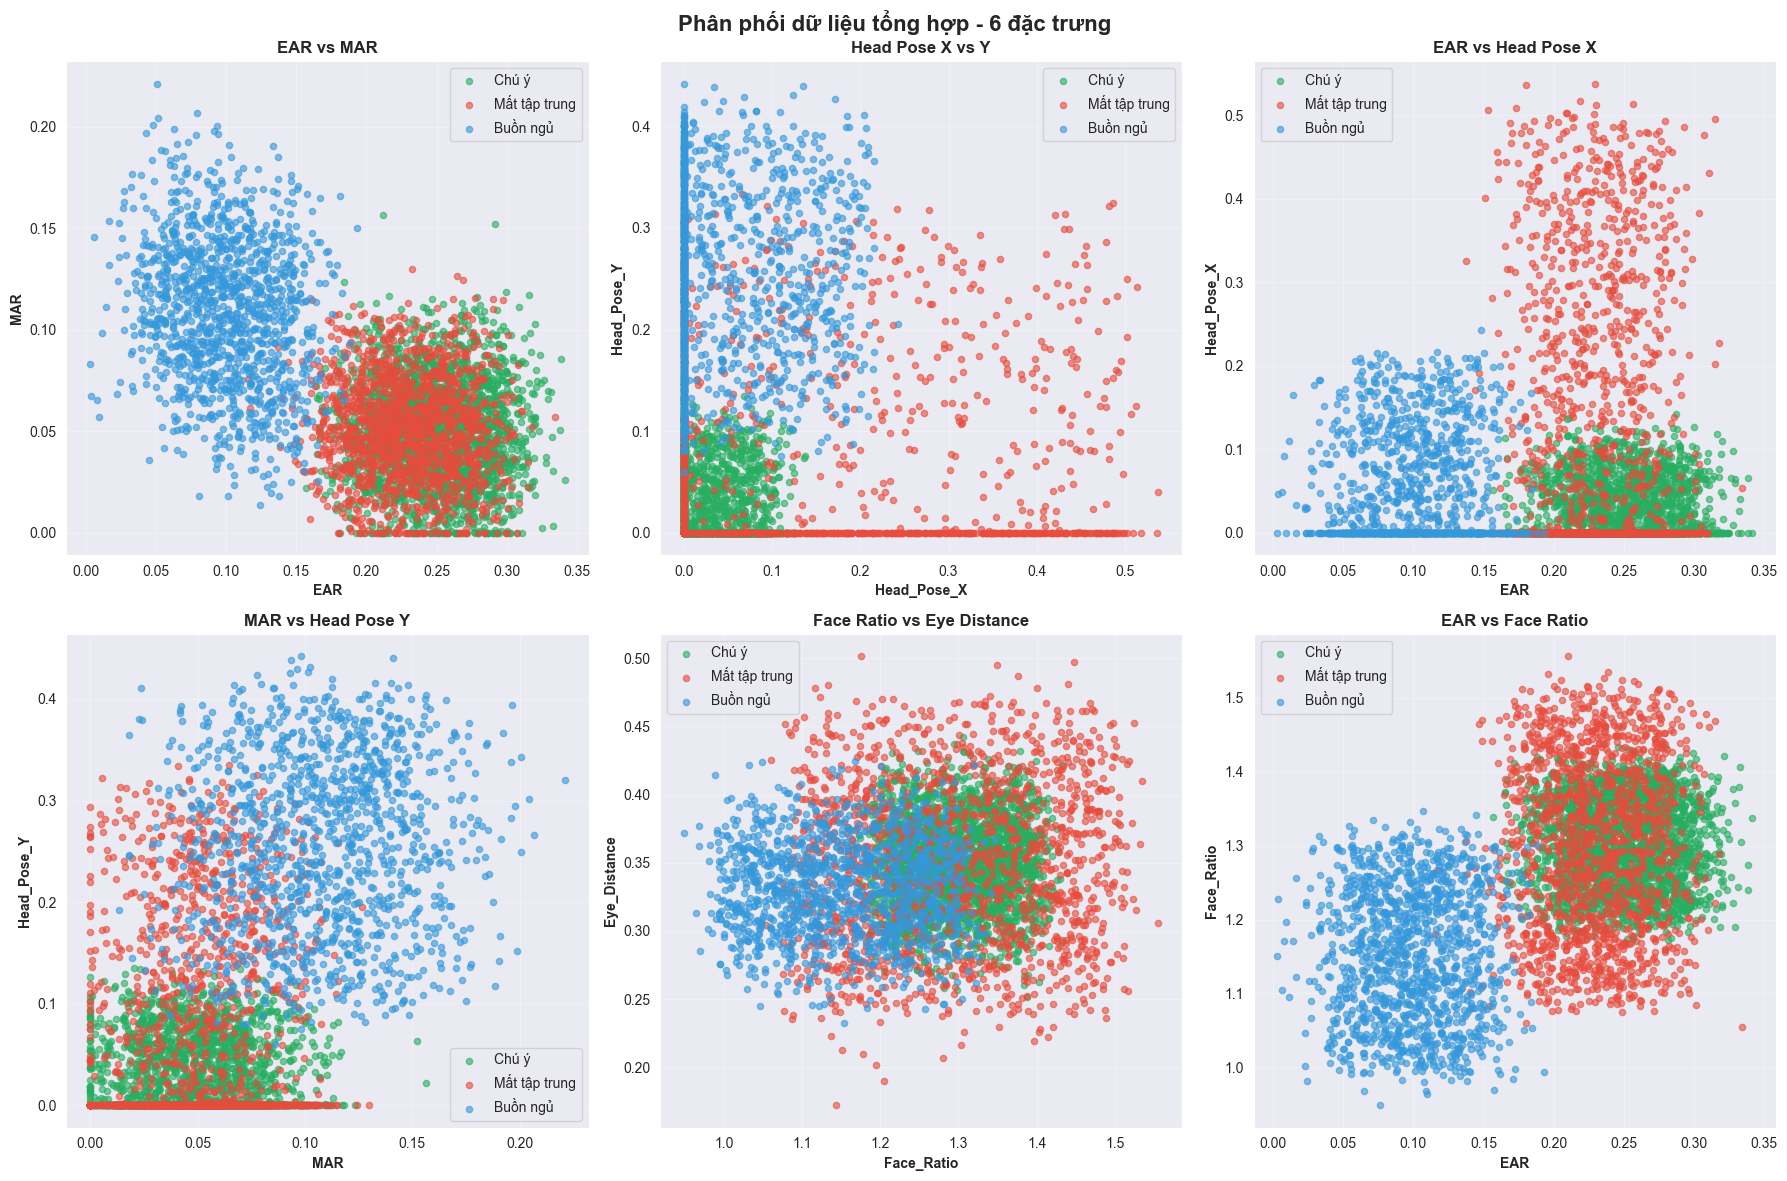

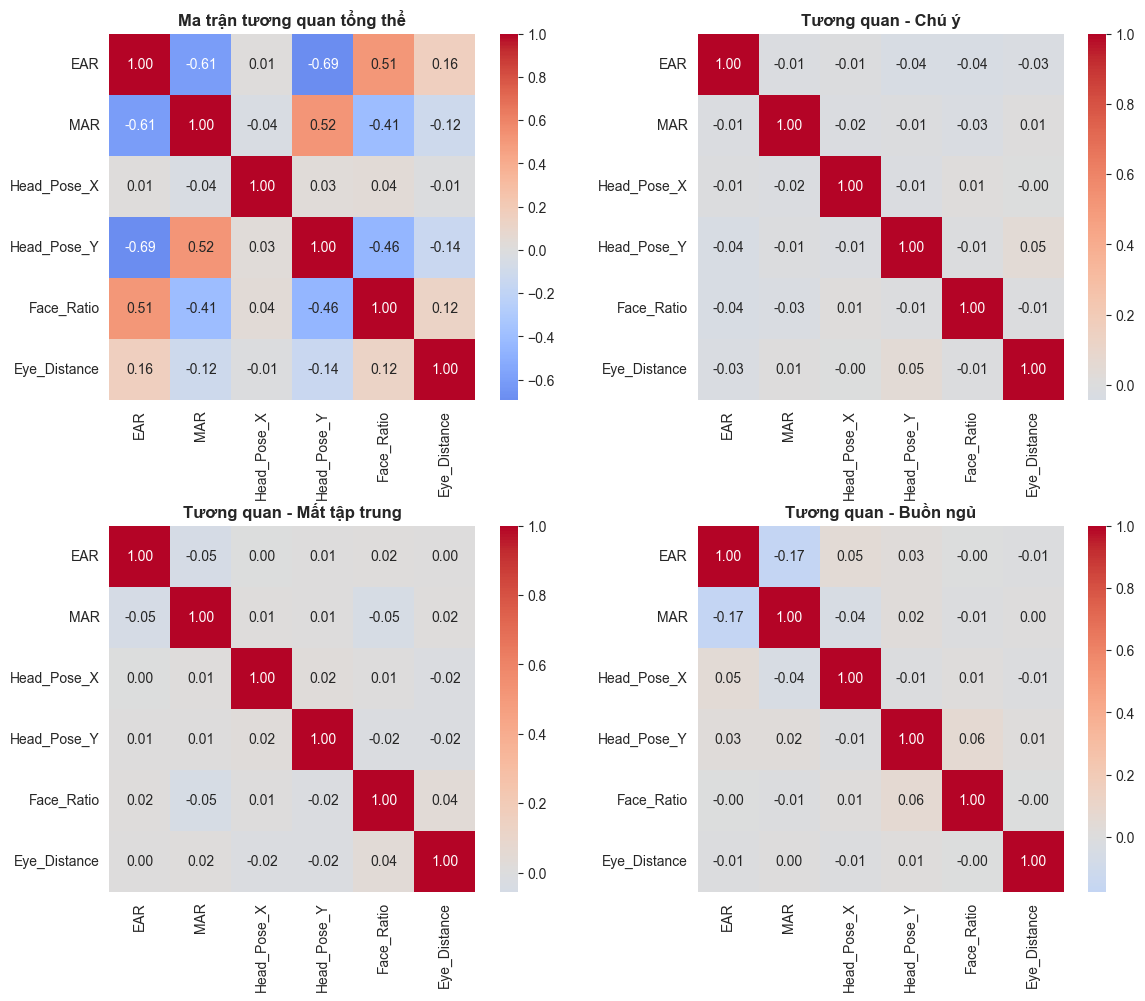


3. HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI
----------------------------------------

  Đang huấn luyện mô hình: random_forest
Khởi tạo AttentionClassifier với mô hình: random_forest
Huấn luyện mô hình random_forest với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.9313
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9590
Độ chính xác kiểm tra: 0.9180
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.88      0.95      0.92       450
Mất tập trung       0.91      0.80      0.85       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.93      0.92      0.92      1000
 weighted avg       0.92      0.92      0.92

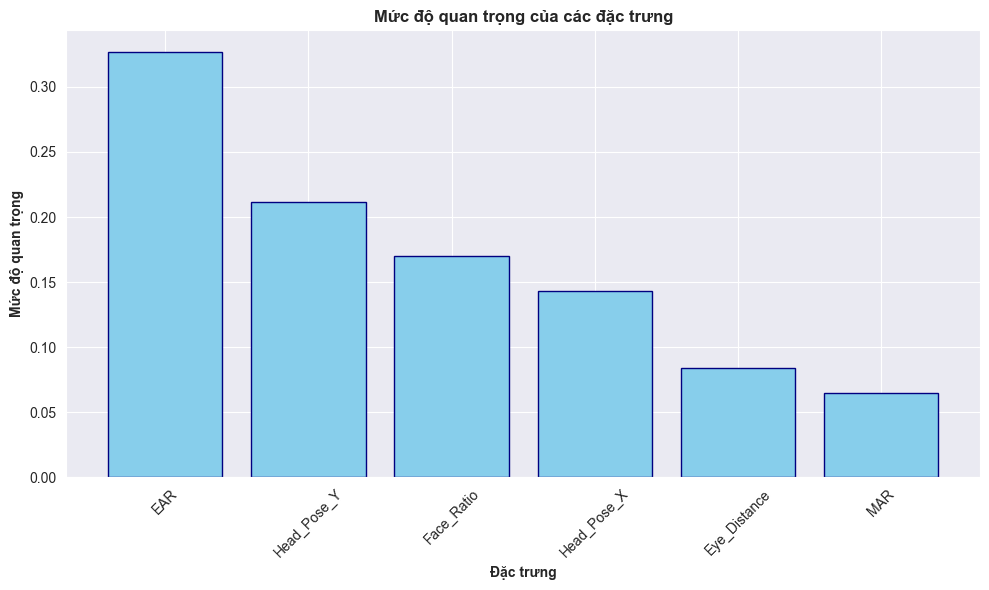

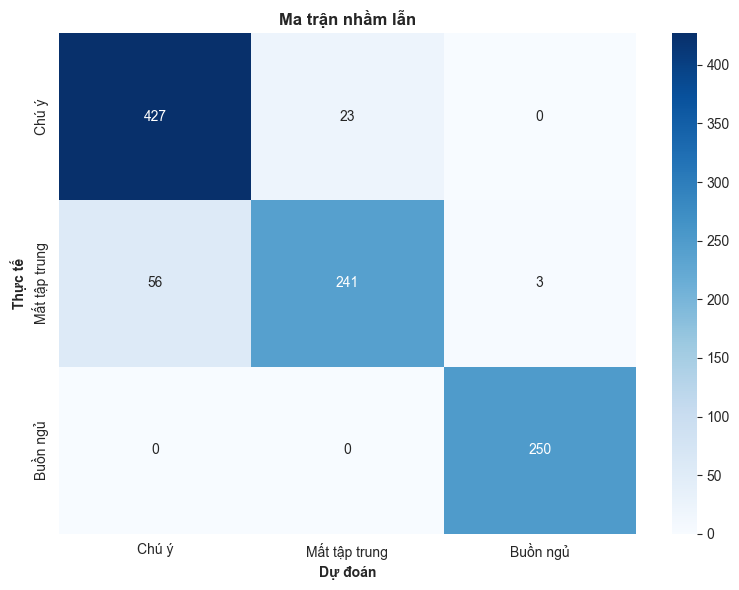

  ✓ random_forest: Accuracy = 0.9180

  Đang huấn luyện mô hình: svm
Khởi tạo AttentionClassifier với mô hình: svm
Huấn luyện mô hình svm với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9332
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9403
Độ chính xác kiểm tra: 0.9200
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.87      0.98      0.92       450
Mất tập trung       0.96      0.76      0.85       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.94      0.91      0.92      1000
 weighted avg       0.93      0.92      0.92      1000



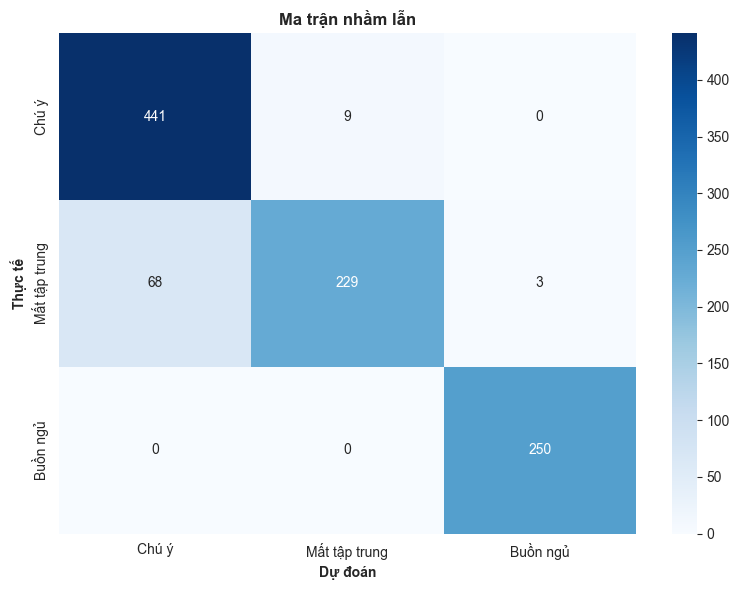

  ✓ svm: Accuracy = 0.9200

  Đang huấn luyện mô hình: neural_network
Khởi tạo AttentionClassifier với mô hình: neural_network
Huấn luyện mô hình neural_network với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate': 'constant'}
Best CV score: 0.9328
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9403
Độ chính xác kiểm tra: 0.9210
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.87      0.97      0.92       450
Mất tập trung       0.95      0.78      0.86       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.94      0.92      0.92      1000
 weighted avg       0.92      0.92      0.92      1000



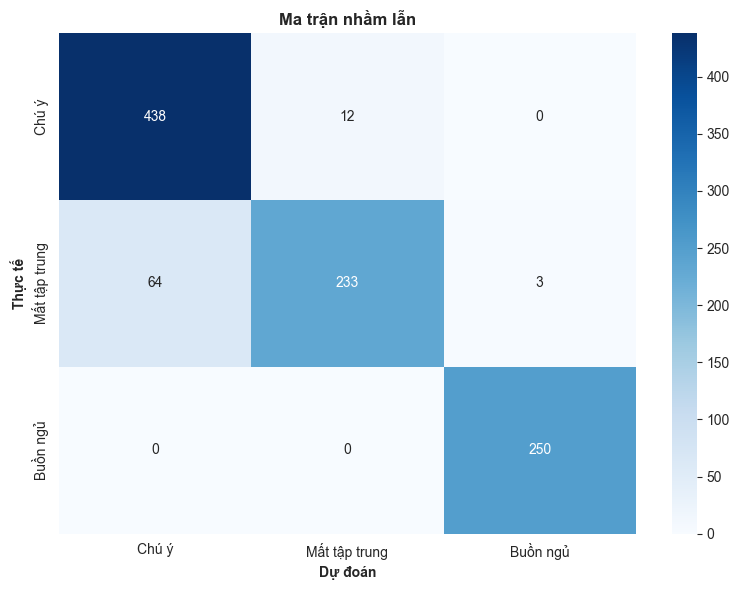

  ✓ neural_network: Accuracy = 0.9210

  🏆 Mô hình tốt nhất: neural_network (Accuracy: 0.9210)
Đã lưu mô hình tại: models/attention_classifier.pkl
  ✓ Đã lưu mô hình tại: models/attention_classifier.pkl

4. KHỞI TẠO HỆ THỐNG THEO DÕI
----------------------------------------
Khởi tạo AttentionMonitoringSystem...
Khởi tạo FaceDetector với phương pháp: mtcnn
Đã khởi tạo MTCNN thành công
Khởi tạo FaceFeatureExtractor với phương pháp: mediapipe
Đã khởi tạo MediaPipe Face Mesh
Khởi tạo AttentionClassifier với mô hình: random_forest
Đã tải mô hình neural_network
Đã khởi tạo AttentionMonitoringSystem thành công
✓ Đã khởi tạo hệ thống theo dõi thành công

5. ĐÁNH GIÁ HIỆU SUẤT HỆ THỐNG
----------------------------------------
Phân tích hiệu suất hệ thống trên 50 ảnh...


I0000 00:00:1748673530.833069 19864345 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
W0000 00:00:1748673530.847712 20086104 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1748673530.865849 20086105 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



BÁO CÁO PHÂN TÍCH HIỆU SUẤT HỆ THỐNG
Tổng số ảnh xử lý: 50
Ảnh có khuôn mặt: 50
Tỷ lệ phát hiện khuôn mặt: 100.00%
Tổng số khuôn mặt: 54
Thời gian xử lý trung bình: 0.0311s
Confidence trung bình: 0.9018

Phân phối trạng thái:
  Chú ý: 0 (0.0%)
  Mất tập trung: 20 (40.0%)
  Buồn ngủ: 27 (54.0%)
  Khác: 3 (6.0%)


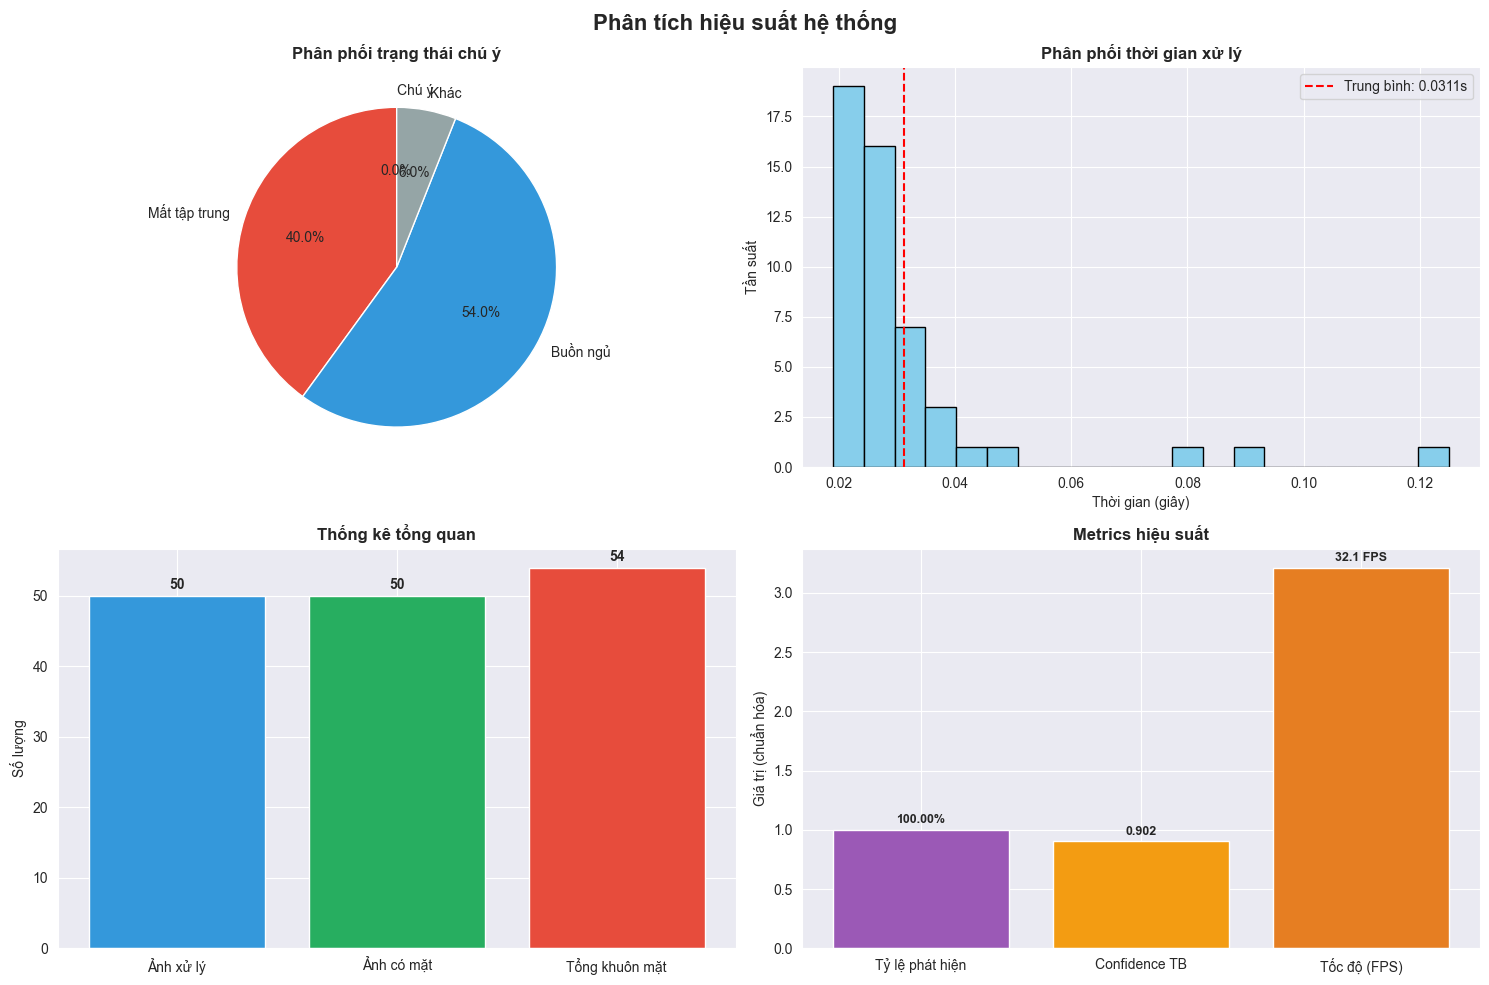


6. TẠO BÁO CÁO TỔNG HỢP
----------------------------------------
Kết quả so sánh các mô hình:
         Model  Accuracy Status
 random_forest     0.918      ✓
           svm     0.920      ✓
neural_network     0.921      ✓

✓ Đã lưu báo cáo hoàn chỉnh tại: complete_analysis_results/complete_pipeline_report.json

HOÀN THÀNH PIPELINE - HỆ THỐNG SẴN SÀNG SỬ DỤNG

🎉 HỆ THỐNG ĐÃ HOÀN THÀNH THÀNH CÔNG!
📁 Kiểm tra các thư mục sau để xem kết quả:
  - models/: Mô hình đã huấn luyện
  - complete_analysis_results/: Báo cáo chi tiết
  - demo_results/: Kết quả demo (nếu có)


In [15]:

# Hàm main để chạy toàn bộ hệ thống
def main():
    """
    Hàm chính để chạy toàn bộ pipeline
    """
    # Cấu hình đường dẫn
    DATASET_PATH = 'datasets/WIDER_FACE'  # Thay đổi theo đường dẫn thực tế
    MODEL_PATH = 'models/attention_classifier.pkl'

    print("🚀 KHỞI ĐỘNG HỆ THỐNG THEO DÕI SỰ CHÚ Ý")
    print("="*60)

    # Kiểm tra dataset
    if not os.path.exists(DATASET_PATH):
        print(f"⚠️  Không tìm thấy dataset tại: {DATASET_PATH}")
        print("Vui lòng cập nhật đường dẫn DATASET_PATH trong hàm main()")
        return

    try:
        # Chạy pipeline hoàn chỉnh
        pipeline_results = create_complete_pipeline(DATASET_PATH, MODEL_PATH)

        if pipeline_results is None:
            print("❌ Pipeline thất bại")
            return

        monitoring_system = pipeline_results['monitoring_system']

        # Demo real-time (tùy chọn)
        demo_choice = input("\n🎥 Bạn có muốn chạy demo webcam không? (y/n): ").lower().strip()

        if demo_choice == 'y':
            demo_report = demo_real_time_monitoring(monitoring_system, duration_seconds=30)

            if demo_report:
                # Lưu kết quả demo
                monitoring_system.save_results('demo_results')

        print("\n🎉 HỆ THỐNG ĐÃ HOÀN THÀNH THÀNH CÔNG!")
        print("📁 Kiểm tra các thư mục sau để xem kết quả:")
        print("  - models/: Mô hình đã huấn luyện")
        print("  - complete_analysis_results/: Báo cáo chi tiết")
        print("  - demo_results/: Kết quả demo (nếu có)")

    except Exception as e:
        print(f"❌ Lỗi trong quá trình chạy pipeline: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

🚀 KHỞI ĐỘNG HỆ THỐNG THEO DÕI SỰ CHÚ Ý
BẮT ĐẦU PIPELINE HOÀN CHỈNH - HỆ THỐNG THEO DÕI SỰ CHÚ Ý

1. KHỞI TẠO DATASET LOADER
----------------------------------------
Khởi tạo DatasetLoader cho: datasets/WIDER_FACE
Đang tải ảnh từ dataset (tối đa 100 người, 10 ảnh/người)...
Đã tải 175 ảnh từ 100 người
✓ Đã tải dataset thành công: 175 ảnh

2. TẠO DỮ LIỆU TỔNG HỢP
----------------------------------------
Tạo 5000 mẫu với phân phối: [2250, 1500, 1250]
Đã tạo dữ liệu tổng hợp: (5000, 6)
✓ Đã tạo dữ liệu tổng hợp: (5000, 6)
  - Đang tạo biểu đồ trực quan hóa...


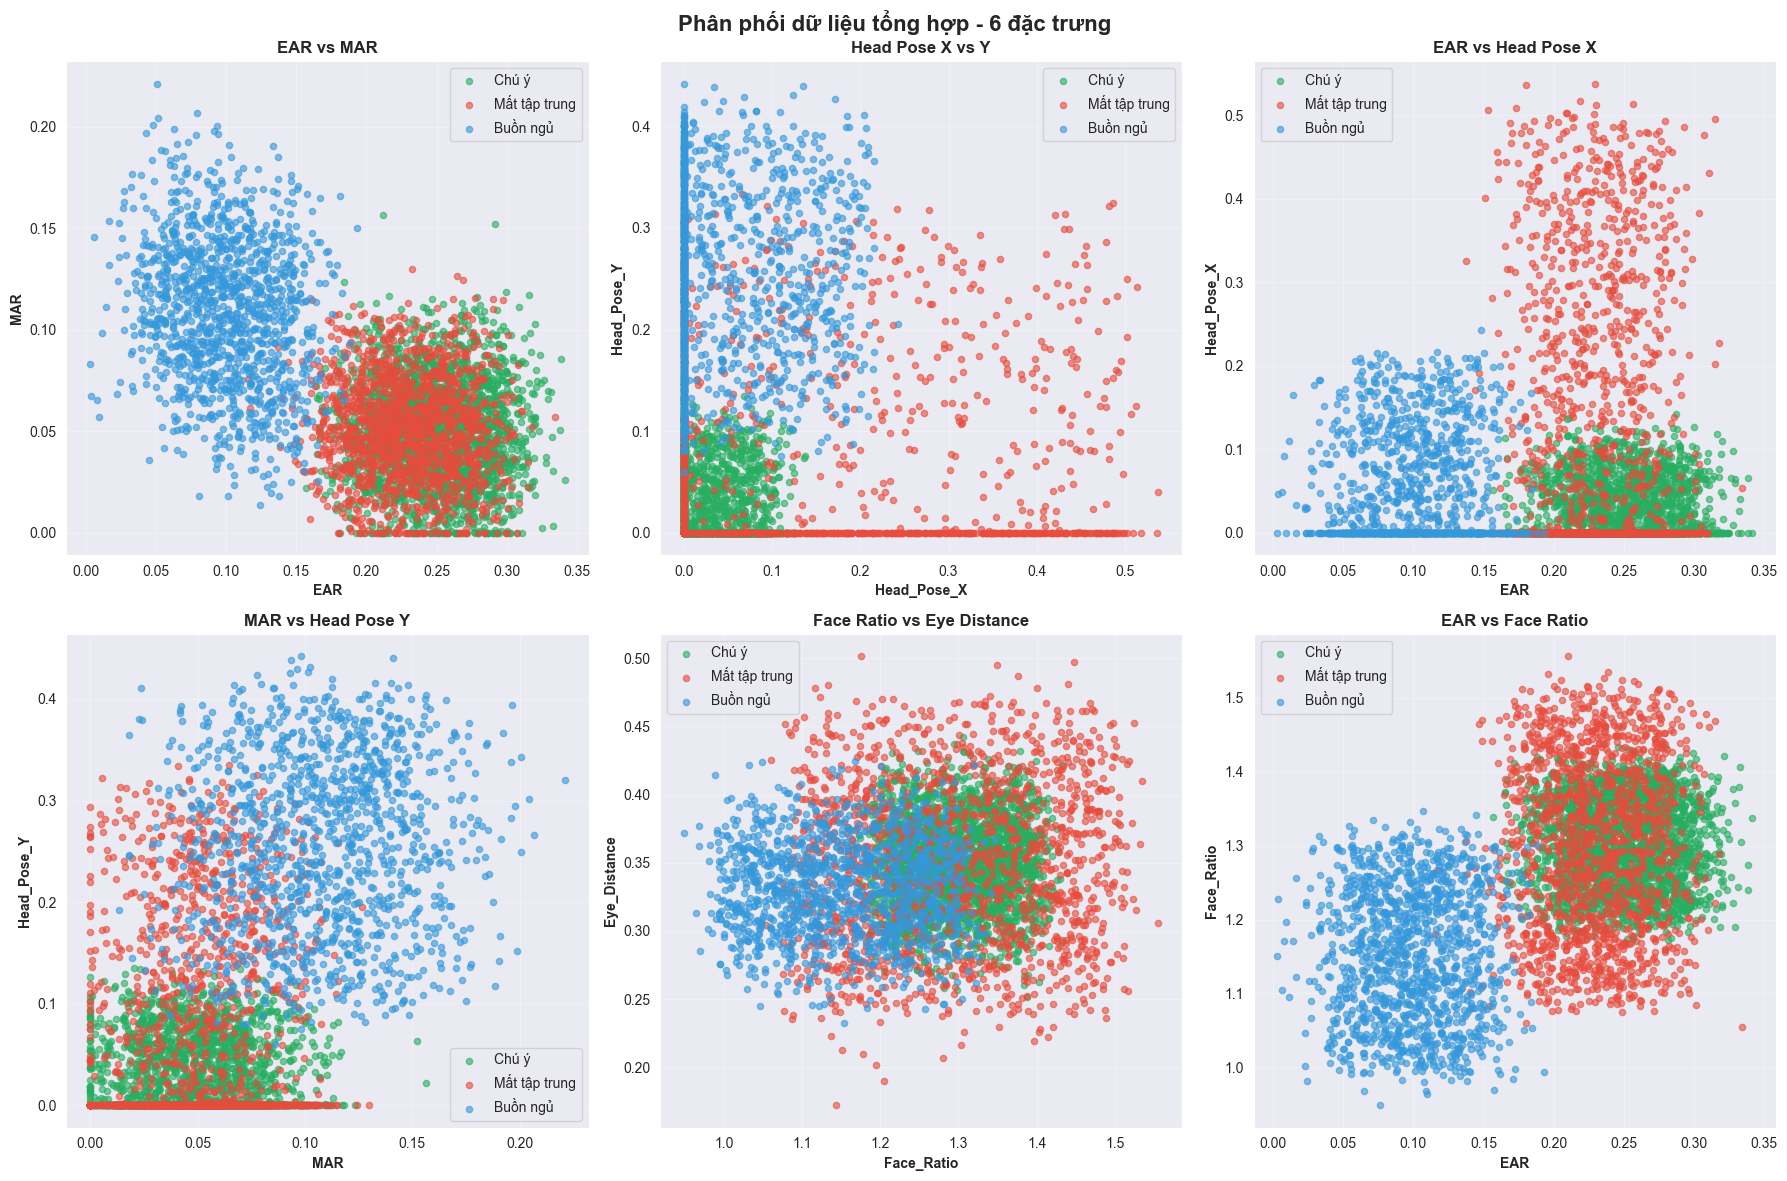

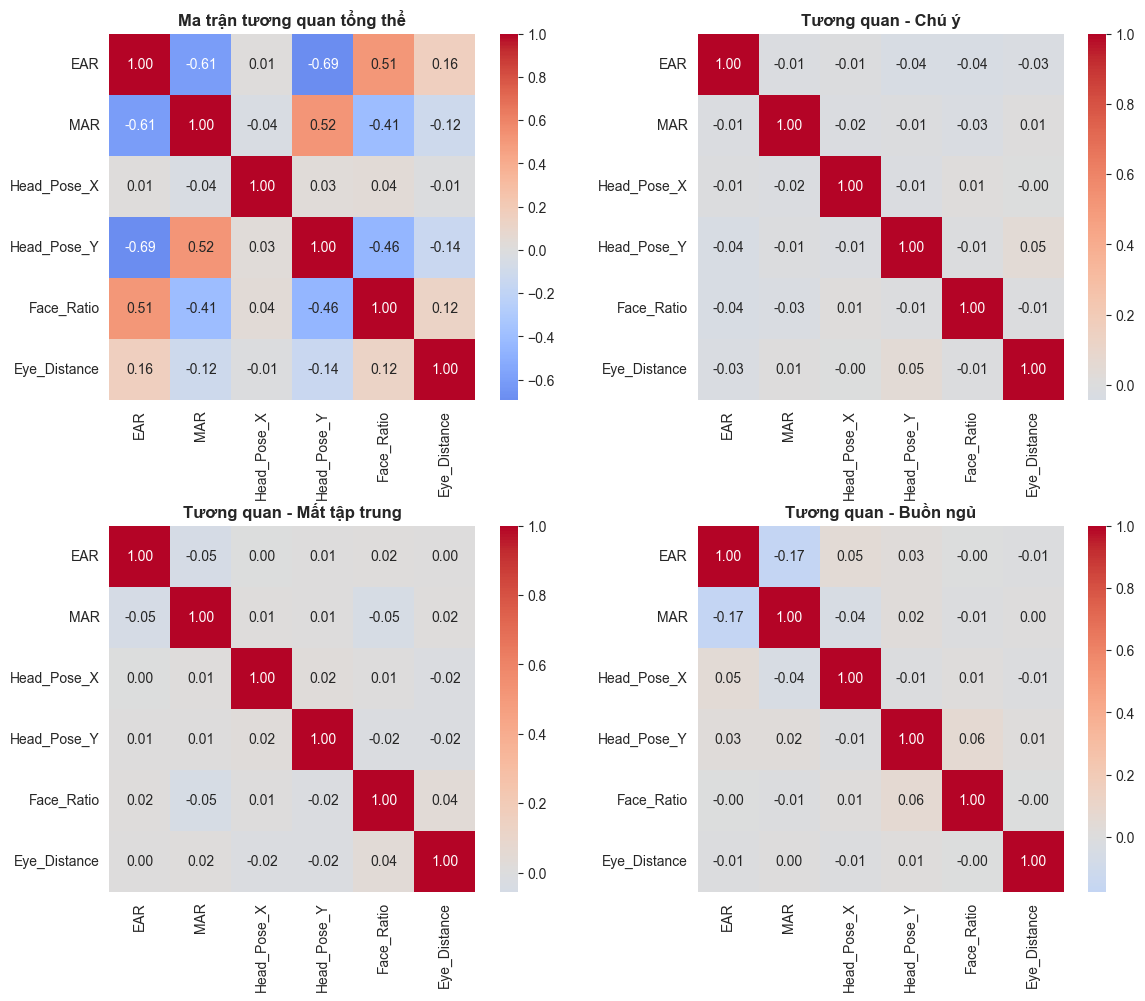


3. HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI
----------------------------------------

  Đang huấn luyện mô hình: random_forest
Khởi tạo AttentionClassifier với mô hình: random_forest
Huấn luyện mô hình random_forest với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.9313
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9590
Độ chính xác kiểm tra: 0.9180
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.88      0.95      0.92       450
Mất tập trung       0.91      0.80      0.85       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.93      0.92      0.92      1000
 weighted avg       0.92      0.92      0.92

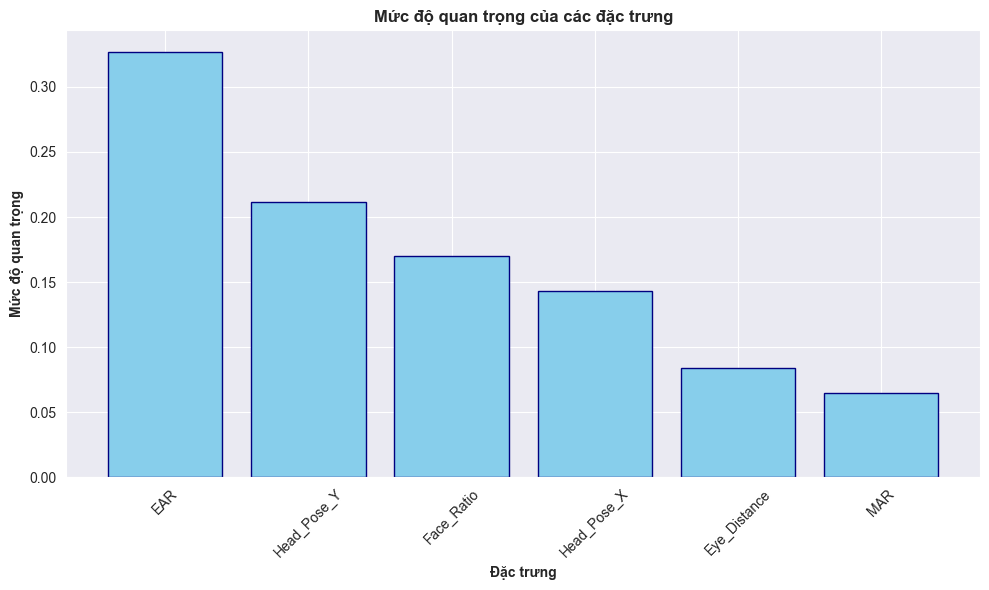

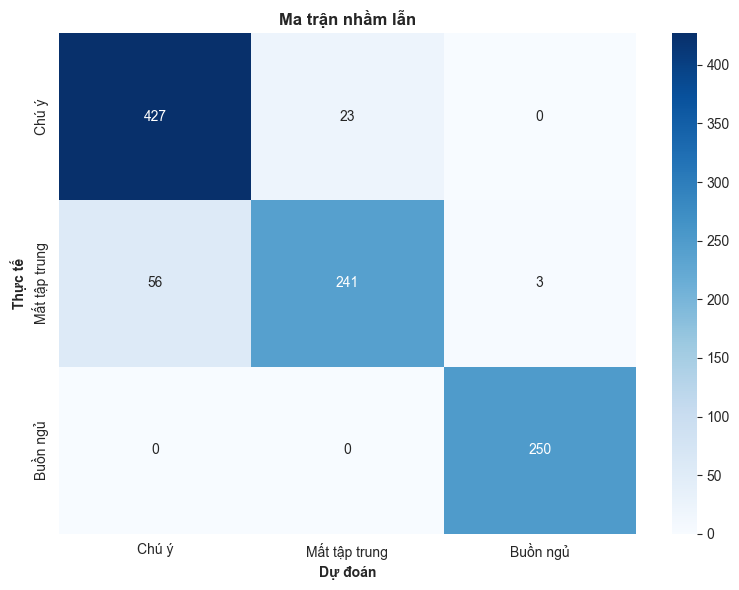

  ✓ random_forest: Accuracy = 0.9180

  Đang huấn luyện mô hình: svm
Khởi tạo AttentionClassifier với mô hình: svm
Huấn luyện mô hình svm với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9332
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9403
Độ chính xác kiểm tra: 0.9200
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.87      0.98      0.92       450
Mất tập trung       0.96      0.76      0.85       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.94      0.91      0.92      1000
 weighted avg       0.93      0.92      0.92      1000



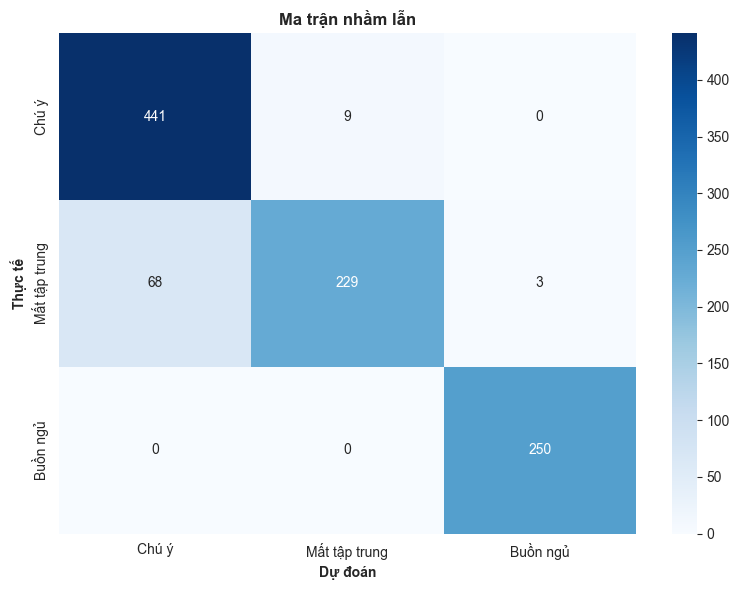

  ✓ svm: Accuracy = 0.9200

  Đang huấn luyện mô hình: neural_network
Khởi tạo AttentionClassifier với mô hình: neural_network
Huấn luyện mô hình neural_network với 5000 mẫu, 6 đặc trưng
Tập huấn luyện: 4000, Tập kiểm tra: 1000
Tối ưu hóa hyperparameters...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate': 'constant'}
Best CV score: 0.9328
Đang huấn luyện mô hình...
Độ chính xác huấn luyện: 0.9403
Độ chính xác kiểm tra: 0.9210
Báo cáo phân loại:
               precision    recall  f1-score   support

        Chú ý       0.87      0.97      0.92       450
Mất tập trung       0.95      0.78      0.86       300
     Buồn ngủ       0.99      1.00      0.99       250

     accuracy                           0.92      1000
    macro avg       0.94      0.92      0.92      1000
 weighted avg       0.92      0.92      0.92      1000



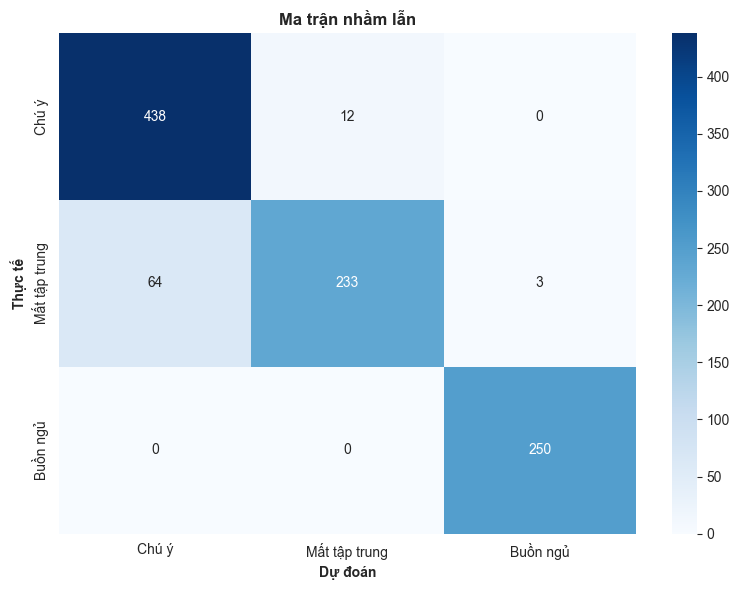

  ✓ neural_network: Accuracy = 0.9210

  🏆 Mô hình tốt nhất: neural_network (Accuracy: 0.9210)
Đã lưu mô hình tại: models/attention_classifier.pkl
  ✓ Đã lưu mô hình tại: models/attention_classifier.pkl

4. KHỞI TẠO HỆ THỐNG THEO DÕI
----------------------------------------
Khởi tạo AttentionMonitoringSystem...
Khởi tạo FaceDetector với phương pháp: mtcnn
Đã khởi tạo MTCNN thành công
Khởi tạo FaceFeatureExtractor với phương pháp: mediapipe
Đã khởi tạo MediaPipe Face Mesh
Khởi tạo AttentionClassifier với mô hình: random_forest
Đã tải mô hình neural_network
Đã khởi tạo AttentionMonitoringSystem thành công
✓ Đã khởi tạo hệ thống theo dõi thành công

5. ĐÁNH GIÁ HIỆU SUẤT HỆ THỐNG
----------------------------------------
Phân tích hiệu suất hệ thống trên 50 ảnh...


I0000 00:00:1748674015.079166 19864345 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
W0000 00:00:1748674015.083059 20144918 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1748674015.099830 20144914 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



BÁO CÁO PHÂN TÍCH HIỆU SUẤT HỆ THỐNG
Tổng số ảnh xử lý: 50
Ảnh có khuôn mặt: 50
Tỷ lệ phát hiện khuôn mặt: 100.00%
Tổng số khuôn mặt: 54
Thời gian xử lý trung bình: 0.0257s
Confidence trung bình: 0.9018

Phân phối trạng thái:
  Chú ý: 0 (0.0%)
  Mất tập trung: 20 (40.0%)
  Buồn ngủ: 27 (54.0%)
  Khác: 3 (6.0%)


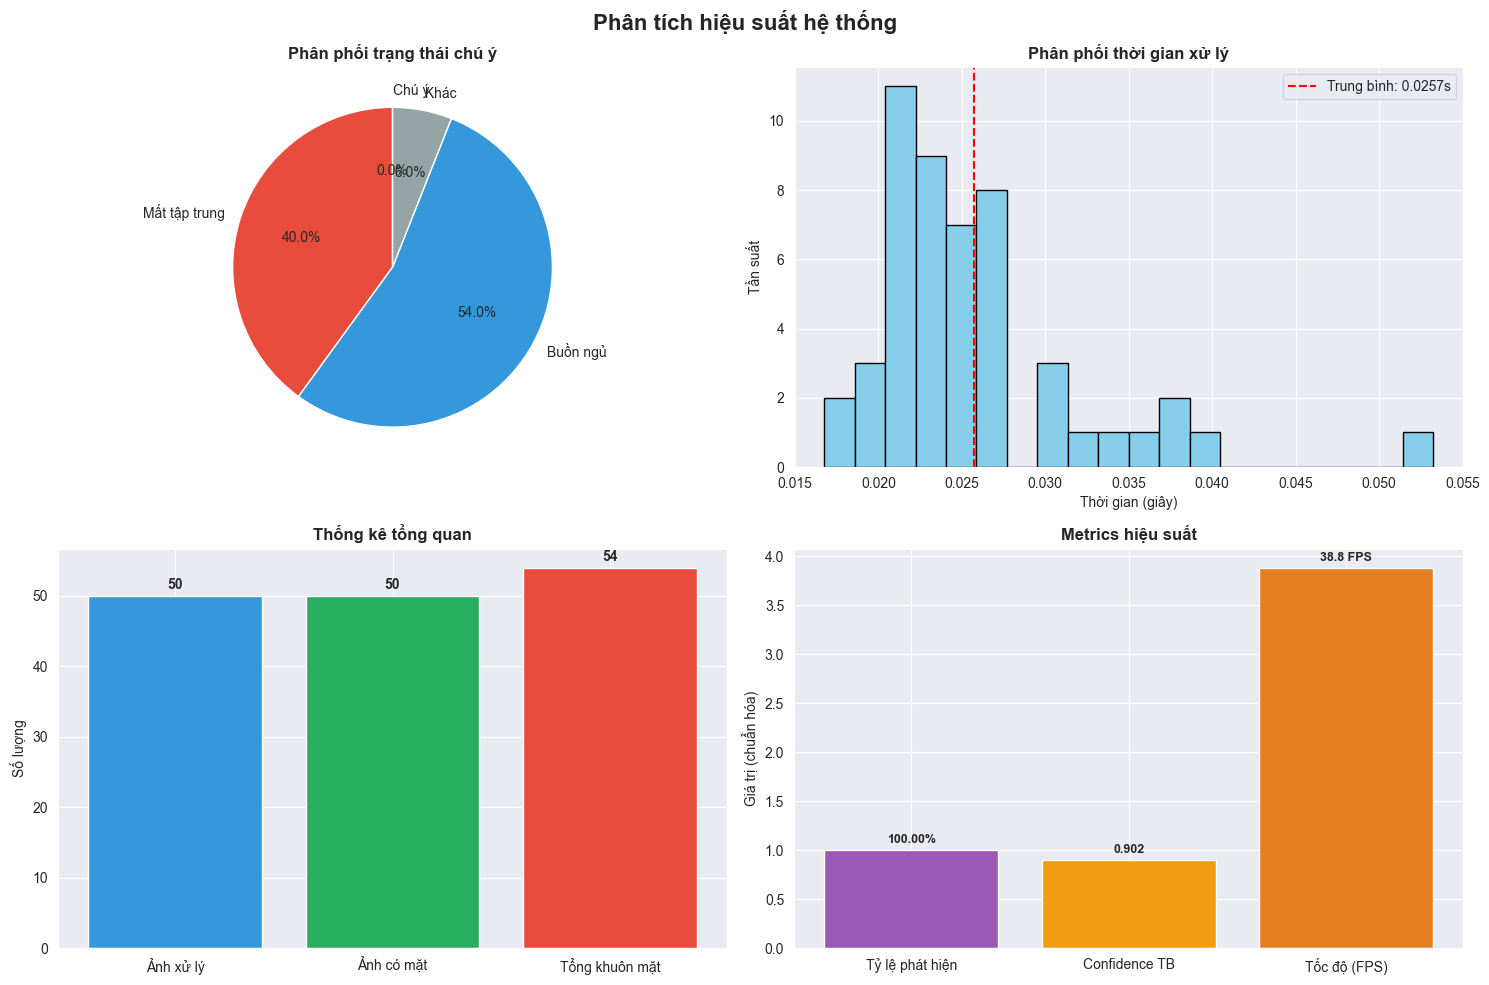


6. TẠO BÁO CÁO TỔNG HỢP
----------------------------------------
Kết quả so sánh các mô hình:
         Model  Accuracy Status
 random_forest     0.918      ✓
           svm     0.920      ✓
neural_network     0.921      ✓

✓ Đã lưu báo cáo hoàn chỉnh tại: complete_analysis_results/complete_pipeline_report.json

HOÀN THÀNH PIPELINE - HỆ THỐNG SẴN SÀNG SỬ DỤNG

🎉 HỆ THỐNG ĐÃ HOÀN THÀNH THÀNH CÔNG!
📁 Kiểm tra các thư mục sau để xem kết quả:
  - models/: Mô hình đã huấn luyện
  - complete_analysis_results/: Báo cáo chi tiết
  - demo_results/: Kết quả demo (nếu có)


In [17]:

# Hàm main để chạy toàn bộ hệ thống
def main():
    """
    Hàm chính để chạy toàn bộ pipeline
    """
    # Cấu hình đường dẫn
    DATASET_PATH = 'datasets/WIDER_FACE'  # Thay đổi theo đường dẫn thực tế
    MODEL_PATH = 'models/attention_classifier.pkl'

    print("🚀 KHỞI ĐỘNG HỆ THỐNG THEO DÕI SỰ CHÚ Ý")
    print("="*60)

    # Kiểm tra dataset
    if not os.path.exists(DATASET_PATH):
        print(f"⚠️  Không tìm thấy dataset tại: {DATASET_PATH}")
        print("Vui lòng cập nhật đường dẫn DATASET_PATH trong hàm main()")
        return

    try:
        # Chạy pipeline hoàn chỉnh
        pipeline_results = create_complete_pipeline(DATASET_PATH, MODEL_PATH)

        if pipeline_results is None:
            print("❌ Pipeline thất bại")
            return

        monitoring_system = pipeline_results['monitoring_system']

        # Demo real-time (tùy chọn)
        demo_choice = input("\n🎥 Bạn có muốn chạy demo webcam không? (y/n): ").lower().strip()

        if demo_choice == 'y':
            demo_report = demo_real_time_monitoring(monitoring_system, duration_seconds=30)

            if demo_report:
                # Lưu kết quả demo
                monitoring_system.save_results('demo_results')

        print("\n🎉 HỆ THỐNG ĐÃ HOÀN THÀNH THÀNH CÔNG!")
        print("📁 Kiểm tra các thư mục sau để xem kết quả:")
        print("  - models/: Mô hình đã huấn luyện")
        print("  - complete_analysis_results/: Báo cáo chi tiết")
        print("  - demo_results/: Kết quả demo (nếu có)")

    except Exception as e:
        print(f"❌ Lỗi trong quá trình chạy pipeline: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()